In [1]:
import pandas as pd
import numpy as np
player_valuations = pd.read_csv('../data/player_valuations.csv')
players = pd.read_csv('../data/players.csv')
appearances = pd.read_csv('../data/appearances.csv')
player_valuations['date'] = pd.to_datetime(player_valuations['date'])
appearances['date'] = pd.to_datetime(appearances['date'])
players['date_of_birth'] = pd.to_datetime(players['date_of_birth'])
max_date = player_valuations['date'].max()

In [2]:
fresh_days = [90, 180, 365, 540]
current_valuations = player_valuations.sort_values(by='date').groupby('player_id').tail(1)[['player_id', 'market_value_in_eur', 'date']].rename(columns={'market_value_in_eur': 'current_value', 'date': 'current_date'})
current_valuations['days_since_update'] = (max_date - current_valuations['current_date']).dt.days
for i in fresh_days:
    fresh_valuations =current_valuations[current_valuations['days_since_update'] <= i].copy()
    print(f"Days since update: {i}, number of players: {len(fresh_valuations)}")

Days since update: 90, number of players: 5515
Days since update: 180, number of players: 5817
Days since update: 365, number of players: 6005
Days since update: 540, number of players: 6037


In [3]:
def build_dataset(fresh_days):
    current_valuations = player_valuations.sort_values(by='date').groupby('player_id').tail(1)[['player_id', 'market_value_in_eur', 'date']].rename(columns={'market_value_in_eur': 'current_value', 'date': 'current_date'})
    current_valuations['days_since_update'] = (max_date - current_valuations['current_date']).dt.days
    fresh_valuations = current_valuations[current_valuations['days_since_update'] <= fresh_days].copy()
    appearances_dated = appearances.merge(fresh_valuations[['player_id', 'current_date']], on='player_id', how='inner')
    appearances_valid = appearances_dated[appearances_dated['date'] <= appearances_dated['current_date']]
    
    stats = appearances_valid.groupby('player_id').agg(
        total_goals=('goals', 'sum'),
        total_assists=('assists', 'sum'),
        total_minutes=('minutes_played', 'sum'),
        total_appearances=('appearance_id', 'count'),
        total_yellow_cards=('yellow_cards', 'sum'),
        total_red_cards=('red_cards', 'sum')
    ).reset_index()
    df = fresh_valuations.merge(stats, on='player_id', how='inner')
    df = df.merge(
        players[['player_id', 'date_of_birth', 'position', 'sub_position', 'foot', 'height_in_cm']],
        on='player_id', how='inner'
    )
    
    df['age'] = (df['current_date'] - df['date_of_birth']).dt.days / 365.25
    df['foot'] = df['foot'].fillna('unknown')
    df['height_in_cm'] = df.groupby('position')['height_in_cm'].transform(lambda x: x.fillna(x.median()))
    df = df.dropna(subset=['age', 'sub_position'])
    
    df['goals_per_90'] = df['total_goals'] * 90 / df['total_minutes']
    df['assists_per_90'] = df['total_assists'] * 90 / df['total_minutes']
    df['log_value'] = np.log1p(df['current_value'])
    df['age_squared'] = df['age'] ** 2
    
    return df

In [4]:
days = [90, 180, 365, 540]
data_summary = []
dataset_dict = {}
for fresh_days in days:
    df = build_dataset(fresh_days)
    dataset_dict[fresh_days] = df
    datarows = {
        'days': fresh_days,
        'players': len(df),
        'median_value': df['current_value'].median(),
        'mean_value': df['current_value'].mean(),
        'median_log_value': df['log_value'].median(),
        'attack': (df['position'] == 'Attack').mean(),
        'midfield': (df['position'] == 'Midfield').mean(),
        'defender': (df['position'] == 'Defender').mean(),
        'goalkeeper': (df['position'] == 'Goalkeeper').mean()}
    data_summary.append(datarows)
results_df = pd.DataFrame(data_summary)
print(results_df)

   days  players  median_value    mean_value  median_log_value    attack  \
0    90     5173     1300000.0  5.918892e+06         14.077876  0.279528   
1   180     5447     1200000.0  5.654233e+06         13.997833  0.280705   
2   365     5585     1000000.0  5.529667e+06         13.815512  0.281110   
3   540     5610     1000000.0  5.506331e+06         13.815512  0.280392   

   midfield  defender  goalkeeper  
0  0.295187  0.331916    0.093369  
1  0.295392  0.331375    0.092528  
2  0.295255  0.329454    0.094181  
3  0.295009  0.330125    0.094474  


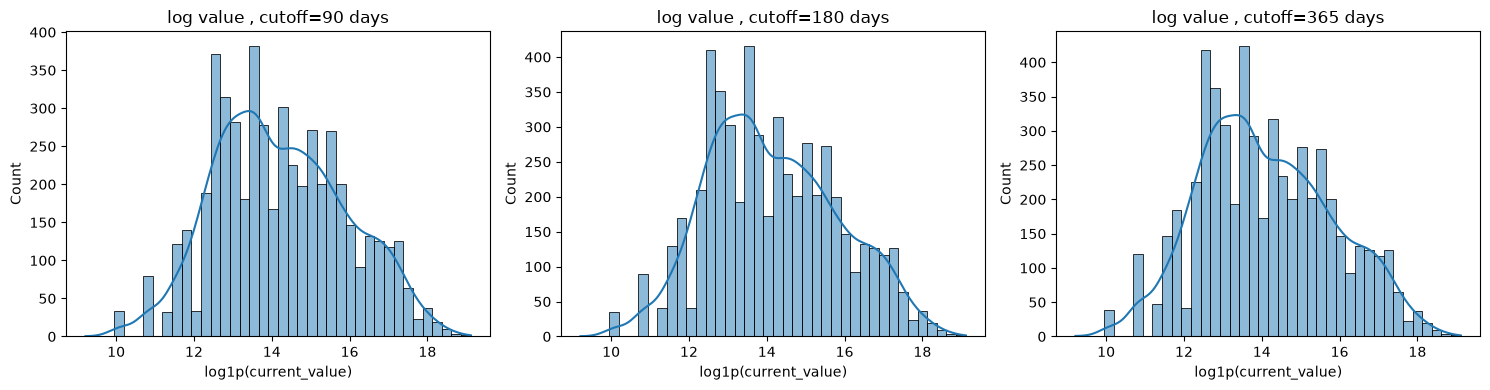

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, cutoff in zip(axes, days):
    sns.histplot(np.log1p(dataset_dict[cutoff]['current_value']), bins=40, kde=True, ax=ax)
    ax.set_title(f'log value , cutoff={cutoff} days')
    ax.set_xlabel('log1p(current_value)')

plt.tight_layout()

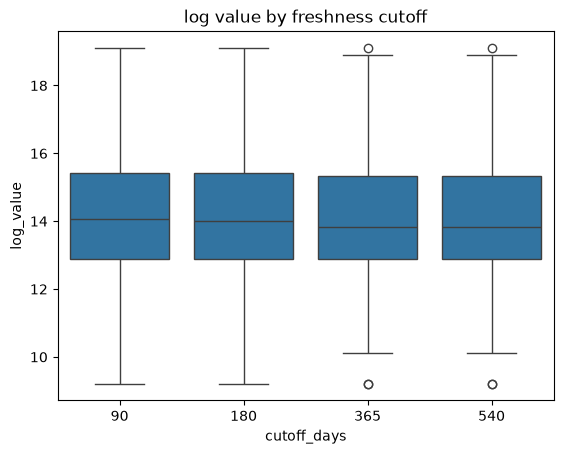

In [6]:
combined = pd.concat([dataset_dict[c].assign(cutoff_days=c) for c in days], ignore_index=True)

sns.boxplot(data=combined, x='cutoff_days', y='log_value')
plt.title('log value by freshness cutoff')
plt.show()

In [7]:
results = []

for day in days:
    df = dataset_dict[day]
    X = df[['age', 'age_squared', 'total_goals', 'total_assists', 'total_minutes', 'total_appearances', 'total_yellow_cards', 'total_red_cards', 'position', 'sub_position', 'foot']].copy()
    X = pd.get_dummies(X, columns=['position', 'sub_position', 'foot'], drop_first=True)
    y = df['log_value']
    
    from sklearn.model_selection import train_test_split
    from sklearn.linear_model import LinearRegression
    from sklearn.metrics import mean_squared_error
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    model = LinearRegression()
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    
    results.append({'days': day, 'rmse': rmse})
model_results_df = pd.DataFrame(results)
print(model_results_df)

   days      rmse
0    90  1.286780
1   180  1.263917
2   365  1.377084
3   540  1.319419


In [8]:
from sklearn.ensemble import RandomForestRegressor
def top_players(df, top_n=20):
    X = df[['age', 'age_squared', 'goals_per_90', 'assists_per_90', 'total_minutes', 'position']]
    X = pd.get_dummies(X, columns=['position'], drop_first=True)
    y = df['log_value']
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    rf = RandomForestRegressor(n_estimators=200, random_state=42)
    rf.fit(X_train, y_train)
    pred = rf.predict(X_test)
    out = df.loc[X_test.index, ['player_id', 'name']].copy()
    out['residual'] = y_test.values - pred
    undervalued = set(out.sort_values('residual').head(top_n)['name'].tolist())
    overvalued = set(out.sort_values('residual', ascending=False).head(top_n)['name'].tolist())
    return undervalued, overvalued

pairs = {}
for day in days:
    pairs[day] = top_players(dataset_dict[day].merge(players[['player_id', 'name']], on='player_id', how='left'), top_n=20)

base_under, base_over = pairs[365]

stability_rows = []
for day in days:
    under, over = pairs[day]
    stability_rows.append({
        'days': day,
        'undervalued_overlap_with_365': len(under & base_under) / 20,
        'overvalued_overlap_with_365': len(over & base_over) / 20,
    })

print(pd.DataFrame(stability_rows))


   days  undervalued_overlap_with_365  overvalued_overlap_with_365
0    90                           0.1                         0.15
1   180                           0.1                         0.15
2   365                           1.0                         1.00
3   540                           0.2                         0.25
